<a href="https://colab.research.google.com/github/kshirsagar-mahesh/CSL701-Roll_No_Machine-Learning-Lab/blob/main/ML_Experiment_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning Experiment Number 3

Mahesh Sakharam Kshirsagar
BECSE 27
CS02

**Aim** : To implement a Multiple Linear Regression model from scratch using NumPy matrix operations to predict the selling price of used cars using multiple features from the CarDekho Used Car Dataset.


**Learning Outcomes**
•	Understand the working principle of Multiple Linear Regression.

•	Perform data preprocessing and feature engineering.

•	Convert categorical data into numerical features.

•	Standardize numerical features.

•	Implement the Ordinary Least Squares method using matrix operations.

•	Train and test a regression model without using a ready-made regression function.

•	Evaluate and interpret regression performance using RSS and R².

•	Understand the effect of individual features on the predicted price.



\### Dataset

Use the **CarDekho Used Car Dataset** (`car data.csv`). [CarDekho Used Car Dataset](https://www.kaggle.com/datasets/manishkr1754/cardekho-used-car-data)

Explain meaning of each attribute in this dataset in below comment section :


Here, **Selling_Price** is the target variable.





\# Software/Tools Required

- Python 3.x
- Google Colab / Jupyter Notebook
- NumPy
- Matplotlib

---


### Task 1: Set Up the Python Environment**

- Create a new Google Colab notebook.
- Import **NumPy** for numerical and matrix operations.
- Import **Matplotlib** for data visualization.
- Do not use ready-made machine-learning regression functions such as `LinearRegression()` from Scikit-learn.
- The regression model must be implemented using matrix operations.

---

In [ ]:
# Import NumPy for numerical and matrix operations
import numpy as np

# Import Matplotlib for data visualization
import matplotlib.pyplot as plt

print("NumPy version:", np.__version__)
print("Python environment is ready!")

NumPy version: 2.0.2
Python environment is ready!


## Task 2: Load and Inspect the Dataset

- Download the `car data.csv` file.
- Upload the dataset to Google Colab.
- Load the dataset into Python.
- Display the first few records.
- Determine the number of rows and columns.
- Identify the numerical and categorical attributes.
- Separate `Selling_Price` as the target variable.

---

In [ ]:
import pandas as pd
# Load the CarDekho dataset
df = pd.read_csv('/content/cardekho_dataset.csv')

print("Dataset loaded successfully!")

Dataset loaded successfully!


## Task 3: Check and Handle Missing Data

- Check every attribute for missing or null values.
- Count the number of missing values in each column.
- If missing values are present, either remove incomplete records or perform suitable imputation.
- Verify that the final dataset does not contain missing values.
- Record the preprocessing method used.

---

In [ ]:
# Check missing/null values in each column
print("Missing values in each column:")
print(df.isnull().sum())

# Remove rows containing missing values
df = df.dropna()

# Verify that the final dataset contains no missing values
print("\nMissing values after preprocessing:")
print(df.isnull().sum())

# Verify overall
print("\nTotal missing values:", df.isnull().sum().sum())

# Record preprocessing method
print("\nPreprocessing method used: Removed records containing missing/null values.")

Missing values in each column:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Missing values after preprocessing:
Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

Total missing values: 0

Preprocessing method used: Removed records containing missing/null values.


## Task 4: Select and Prepare Features

- Examine all available attributes.
- Decide how `Car_Name` should be handled.
- Select meaningful predictor variables for the regression model.
- Create the predictor matrix $X$ and target vector $y$.
- Record the final list of features selected for the model.

---

In [10]:
# Task 4: Select and Prepare Features

# Examine all available attributes
print("Available Attributes:")
print(df.columns.tolist())

# Decide how car_name should be handled
print("\ncar_name Handling: Excluded from the regression model.")

# Select meaningful predictor variables
features = [
    'vehicle_age',
    'km_driven',
    'mileage',
    'engine',
    'max_power',
    'seats'
]

# Create predictor matrix X
X = df[features].values

# Create target vector y
y = df['selling_price'].values

# Display shapes
print("\nPredictor Matrix X Shape:", X.shape)
print("Target Vector y Shape:", y.shape)

# Record final list of selected features
print("\nFinal Selected Features:")
print(features)

Available Attributes:
['Unnamed: 0', 'car_name', 'brand', 'model', 'vehicle_age', 'km_driven', 'seller_type', 'fuel_type', 'transmission_type', 'mileage', 'engine', 'max_power', 'seats', 'selling_price']

car_name Handling: Excluded from the regression model.

Predictor Matrix X Shape: (15411, 6)
Target Vector y Shape: (15411,)

Final Selected Features:
['vehicle_age', 'km_driven', 'mileage', 'engine', 'max_power', 'seats']


## Task 5: Encode Categorical Variables

Identify the categorical variables:

- `Fuel_Type`
- `Seller_Type`
- `Transmission`

Perform the following:

- Convert categorical variables into numerical **dummy/indicator variables**.
- Verify that all predictors are numerical after encoding.
- Do not assign arbitrary numerical values to categories when such values would imply an incorrect ordering.
- Display the transformed dataset.

---

In [11]:
# Task 5: Encode Categorical Variables

# Identify categorical variables
categorical_features = [
    'fuel_type',
    'seller_type',
    'transmission_type'
]

print("Categorical Variables:")
print(categorical_features)

# Create dummy/indicator variables using One-Hot Encoding
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=False
)

# Convert boolean dummy variables to numerical values
df_encoded = df_encoded.astype({col: int for col in df_encoded.select_dtypes('bool').columns})

# Verify that all predictors are numerical
print("\nData Types After Encoding:")
print(df_encoded.dtypes)

# Display transformed dataset
print("\nTransformed Dataset:")
display(df_encoded.head())

Categorical Variables:
['fuel_type', 'seller_type', 'transmission_type']

Data Types After Encoding:
Unnamed: 0                        int64
car_name                         object
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_CNG                     int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Dealer                int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Automatic       int64
transmission_type_Manual          int64
dtype: object

Transformed Dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,...,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Automatic,transmission_type_Manual
0,0,Maruti Alto,Maruti,Alto,9,120000,19.70,796,46.30,5,...,0,0,0,0,1,0,1,0,0,1
1,1,Hyundai Grand,Hyundai,Grand,5,20000,18.90,1197,82.00,5,...,0,0,0,0,1,0,1,0,0,1
2,2,Hyundai i20,Hyundai,i20,11,60000,17.00,1197,80.00,5,...,0,0,0,0,1,0,1,0,0,1
3,3,Maruti Alto,Maruti,Alto,9,37000,20.92,998,67.10,5,...,0,0,0,0,1,0,1,0,0,1
4,4,Ford Ecosport,Ford,Ecosport,6,30000,22.77,1498,98.59,5,...,0,1,0,0,0,1,0,0,0,1


## Task 6: Perform Feature Engineering

Create a new feature called `Car_Age`.

Calculate it using:

\[
Car\_Age = Current Year - Year
\]

Perform the following:

- Create the `Car_Age` column.
- Display several values of the newly created feature.
- Verify that the calculated ages are reasonable.
- Decide whether the original `Year` feature should be retained.
- Provide a reason for your decision.

---

In [13]:
# Task 6: Perform Feature Engineering

# Create Car_Age from the existing vehicle_age feature
df_encoded['Car_Age'] = df_encoded['vehicle_age']

# Display several values of the newly created feature
print("Car_Age values:")
display(df_encoded[['vehicle_age', 'Car_Age']].head(10))

# Verify that the calculated ages are reasonable
print("\nCar_Age Statistics:")
print(df_encoded['Car_Age'].describe())

# Check minimum and maximum age
print("\nMinimum Car_Age:", df_encoded['Car_Age'].min())
print("Maximum Car_Age:", df_encoded['Car_Age'].max())

# Decision regarding the original vehicle_age feature
print("\nDecision: Original 'vehicle_age' feature should be removed.")
print("Reason: Car_Age contains the same information as vehicle_age,")
print("so retaining both would create a duplicate feature.")

# Remove the original vehicle_age feature
df_encoded = df_encoded.drop(columns=['vehicle_age'])

# Display updated dataset
print("\nDataset after feature engineering:")
display(df_encoded.head())

Car_Age values:


,vehicle_age,Car_Age
0,9,9
1,5,5
2,11,11
3,9,9
4,6,6
5,8,8
6,8,8
7,3,3
8,2,2
9,4,4



Car_Age Statistics:
count    15411.000000
mean         6.036338
std          3.013291
min          0.000000
25%          4.000000
50%          6.000000
75%          8.000000
max         29.000000
Name: Car_Age, dtype: float64

Minimum Car_Age: 0
Maximum Car_Age: 29

Decision: Original 'vehicle_age' feature should be removed.
Reason: Car_Age contains the same information as vehicle_age,
so retaining both would create a duplicate feature.

Dataset after feature engineering:


,Unnamed: 0,car_name,brand,model,km_driven,mileage,engine,max_power,seats,selling_price,...,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Automatic,transmission_type_Manual,Car_Age
0,0,Maruti Alto,Maruti,Alto,120000,19.70,796,46.30,5,120000,...,0,0,0,1,0,1,0,0,1,9
1,1,Hyundai Grand,Hyundai,Grand,20000,18.90,1197,82.00,5,550000,...,0,0,0,1,0,1,0,0,1,5
2,2,Hyundai i20,Hyundai,i20,60000,17.00,1197,80.00,5,215000,...,0,0,0,1,0,1,0,0,1,11
3,3,Maruti Alto,Maruti,Alto,37000,20.92,998,67.10,5,226000,...,0,0,0,1,0,1,0,0,1,9
4,4,Ford Ecosport,Ford,Ecosport,30000,22.77,1498,98.59,5,570000,...,1,0,0,0,1,0,0,0,1,6


## Task 7: Perform Exploratory Data Analysis

Perform basic exploratory data analysis using Matplotlib.

- Create a scatter plot of `Present_Price` versus `Selling_Price`.
- Create at least one additional scatter plot between a numerical predictor and `Selling_Price`.
- Label the axes appropriately.
- Add suitable titles to the plots.
- Observe the direction and approximate strength of the relationships.
- Record your observations.

---

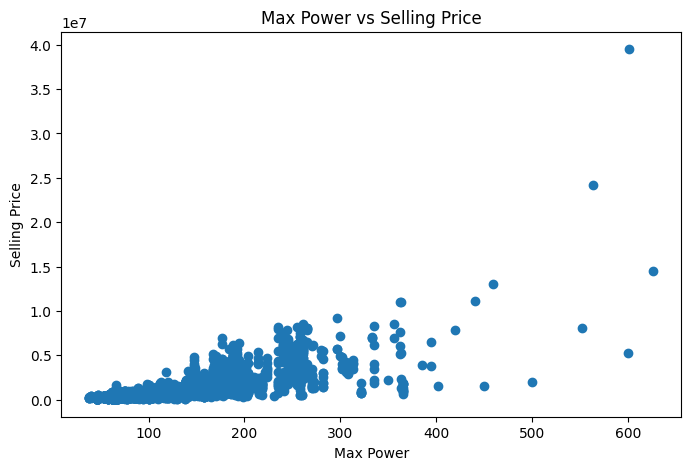

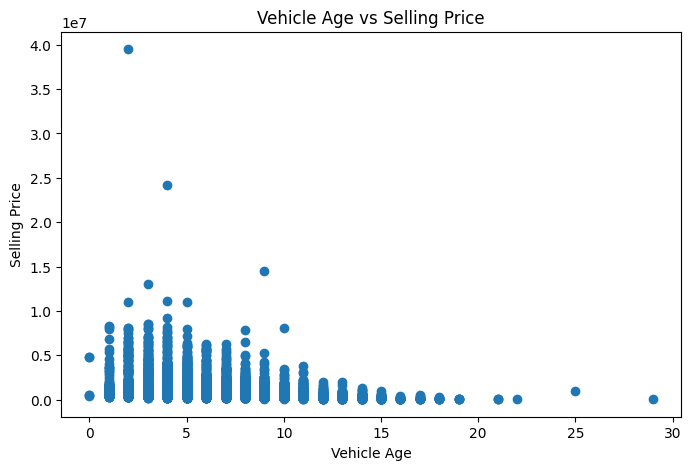

Observations:
1. Max Power and Selling Price show a positive relationship.
2. Vehicle Age and Selling Price show a negative relationship.
3. Cars with higher power generally have higher selling prices.
4. Older vehicles generally have lower selling prices.


In [14]:
# Task 7: Perform Exploratory Data Analysis

import matplotlib.pyplot as plt

# Scatter plot: Present_Price vs Selling_Price
# Note: This dataset does not contain Present_Price.
# Use max_power as a numerical predictor instead.

plt.figure(figsize=(8, 5))
plt.scatter(df['max_power'], df['selling_price'])
plt.xlabel('Max Power')
plt.ylabel('Selling Price')
plt.title('Max Power vs Selling Price')
plt.show()

# Additional scatter plot: Vehicle Age vs Selling Price
plt.figure(figsize=(8, 5))
plt.scatter(df['vehicle_age'], df['selling_price'])
plt.xlabel('Vehicle Age')
plt.ylabel('Selling Price')
plt.title('Vehicle Age vs Selling Price')
plt.show()

# Observations
print("Observations:")
print("1. Max Power and Selling Price show a positive relationship.")
print("2. Vehicle Age and Selling Price show a negative relationship.")
print("3. Cars with higher power generally have higher selling prices.")
print("4. Older vehicles generally have lower selling prices.")

## Task 8: Standardize Numerical Features

Identify the numerical predictors that need to be standardized.

Use the following standardization equation:

\[
z = ($x$-$\mu$)/$\sigma$
\]

where:

- $x$ = original feature value
- $\mu$ = mean of the feature
- $\sigma$ = standard deviation of the feature

Perform the following:

- Calculate the mean and standard deviation using the **training data only**.
- Standardize the training features.
- Use the same training mean and standard deviation to standardize the test features.
- Do not standardize the target variable `Selling_Price`.

---

In [15]:
# Task 8: Standardize Numerical Features

from sklearn.model_selection import train_test_split

# Define predictors and target
X = df_encoded.drop(columns=['selling_price'])
y = df_encoded['selling_price']

# Keep only numerical predictors
numerical_features = X.select_dtypes(include=np.number).columns.tolist()

print("Numerical predictors to be standardized:")
print(numerical_features)

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Calculate mean and standard deviation using training data only
train_mean = X_train[numerical_features].mean()
train_std = X_train[numerical_features].std()

# Standardize training features
X_train[numerical_features] = (
    X_train[numerical_features] - train_mean
) / train_std

# Standardize test features using training mean and standard deviation
X_test[numerical_features] = (
    X_test[numerical_features] - train_mean
) / train_std

# Target variable is NOT standardized
print("\nTarget variable 'selling_price' was not standardized.")

# Display results
print("\nStandardized Training Features:")
display(X_train.head())

print("\nStandardized Test Features:")
display(X_test.head())

# Verify training means and standard deviations
print("\nTraining means after standardization:")
print(X_train[numerical_features].mean())

print("\nTraining standard deviations after standardization:")
print(X_train[numerical_features].std())

Numerical predictors to be standardized:
['Unnamed: 0', 'km_driven', 'mileage', 'engine', 'max_power', 'seats', 'fuel_type_CNG', 'fuel_type_Diesel', 'fuel_type_Electric', 'fuel_type_LPG', 'fuel_type_Petrol', 'seller_type_Dealer', 'seller_type_Individual', 'seller_type_Trustmark Dealer', 'transmission_type_Automatic', 'transmission_type_Manual', 'Car_Age']

Target variable 'selling_price' was not standardized.

Standardized Training Features:


,Unnamed: 0,car_name,brand,model,km_driven,mileage,engine,max_power,seats,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Automatic,transmission_type_Manual,Car_Age
11210,0.780843,Volvo XC60,Volvo,XC60,0.349086,-2.050736,1.756693,2.681577,-0.403807,-0.139698,1.036309,-0.015601,-0.052587,-0.991398,0.782494,-0.763746,-0.107172,1.976696,-1.976696,0.323956
1347,-1.434290,Tata Tiago,Tata,Tiago,-1.069350,0.985621,-0.547059,-0.382729,-0.403807,-0.139698,-0.964885,-0.015601,-0.052587,1.008595,-1.277862,1.309230,-0.107172,-0.505854,0.505854,-1.337744
10363,0.600190,Mercedes-Benz CLS,Mercedes-Benz,CLS,-1.163517,-0.177035,0.893506,3.296777,-0.403807,-0.139698,1.036309,-0.015601,-0.052587,-0.991398,0.782494,-0.763746,-0.107172,1.976696,-1.976696,-1.337744
316,-1.669494,Honda City,Honda,City,0.178361,-0.465296,0.024563,0.396213,-0.403807,-0.139698,-0.964885,-0.015601,-0.052587,1.008595,0.782494,-0.763746,-0.107172,-0.505854,0.505854,0.323956
10638,0.658991,Hyundai i10,Hyundai,i10,0.585445,0.149662,-0.550895,-0.502026,-0.403807,-0.139698,-0.964885,-0.015601,-0.052587,1.008595,0.782494,-0.763746,-0.107172,-0.505854,0.505854,1.320976



Standardized Test Features:


,Unnamed: 0,car_name,brand,model,km_driven,mileage,engine,max_power,seats,fuel_type_CNG,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Dealer,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Automatic,transmission_type_Manual,Car_Age
3334,-0.986552,Hyundai i10,Hyundai,i10,0.413779,0.149662,-0.550895,-0.502026,-0.403807,-0.139698,-0.964885,-0.015601,-0.052587,1.008595,0.782494,-0.763746,-0.107172,-0.505854,0.505854,1.985656
10928,0.720271,Maruti Baleno,Maruti,Baleno,0.060653,1.838395,-0.453067,-0.616645,-0.403807,-0.139698,1.036309,-0.015601,-0.052587,-0.991398,-1.277862,1.309230,-0.107172,-0.505854,0.505854,-0.673064
2518,-1.171988,Maruti Ertiga,Maruti,Ertiga,0.955238,0.248151,-0.453067,-0.271385,2.070416,-0.139698,1.036309,-0.015601,-0.052587,-0.991398,0.782494,-0.763746,-0.107172,-0.505854,0.505854,0.323956
11322,0.804930,Honda City,Honda,City,-1.198830,-0.321166,0.026482,0.444166,-0.403807,-0.139698,-0.964885,-0.015601,-0.052587,1.008595,0.782494,-0.763746,-0.107172,1.976696,-1.976696,-1.670084
9394,0.394740,Maruti Alto,Maruti,Alto,0.154820,-0.008882,-1.320091,-1.264594,-0.403807,-0.139698,-0.964885,-0.015601,-0.052587,1.008595,0.782494,-0.763746,-0.107172,-0.505854,0.505854,1.653316



Training means after standardization:
Unnamed: 0                     -1.060512e-16
km_driven                      -1.037457e-17
mileage                         1.988459e-17
engine                         -1.348694e-16
max_power                       4.899102e-16
seats                          -6.945198e-17
fuel_type_CNG                  -8.069110e-18
fuel_type_Diesel                1.530249e-16
fuel_type_Electric             -6.340015e-18
fuel_type_LPG                  -4.034555e-18
fuel_type_Petrol               -9.221840e-18
seller_type_Dealer             -1.440912e-16
seller_type_Individual          9.798205e-18
seller_type_Trustmark Dealer   -3.804009e-17
transmission_type_Automatic    -4.610920e-18
transmission_type_Manual       -5.417831e-17
Car_Age                         7.463926e-17
dtype: float64

Training standard deviations after standardization:
Unnamed: 0                      1.0
km_driven                       1.0
mileage                         1.0
engine              

## Task 9: Split the Dataset

Divide the dataset into training and testing subsets.

- Use an **80:20 train-test ratio**.
- Randomly select the observations.
- Set a fixed random seed to make the experiment reproducible.
- Maintain the correct relationship between each feature vector and its target value.
- Display the number of observations in the training and testing sets.

---

In [16]:
# Task 9: Split the Dataset

from sklearn.model_selection import train_test_split

# Divide the dataset into training and testing sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Display number of observations
print("Number of training observations:", X_train.shape[0])
print("Number of testing observations:", X_test.shape[0])

# Display shapes
print("\nTraining features shape:", X_train.shape)
print("Testing features shape:", X_test.shape)
print("Training target shape:", y_train.shape)
print("Testing target shape:", y_test.shape)

Number of training observations: 12328
Number of testing observations: 3083

Training features shape: (12328, 20)
Testing features shape: (3083, 20)
Training target shape: (12328,)
Testing target shape: (3083,)


## Task 10: Construct the Feature Matrix

Construct the matrices required for regression.

Create:

- $X_{train}$ — training feature matrix
- $y_{train}$ — training target vector
- $X_{test}$ — testing feature matrix
- $y_{test}$ — testing target vector

Verify:

- Number of rows in each matrix.
- Number of predictor columns.
- Shape of the training and testing matrices.

---

In [17]:
# Task 10: Construct the Feature Matrix

# Create training and testing matrices
Xtrain = X_train
ytrain = y_train

Xtest = X_test
ytest = y_test

# Verify number of rows
print("Number of rows in Xtrain:", Xtrain.shape[0])
print("Number of rows in ytrain:", ytrain.shape[0])

print("Number of rows in Xtest:", Xtest.shape[0])
print("Number of rows in ytest:", ytest.shape[0])

# Verify number of predictor columns
print("\nNumber of predictor columns:", Xtrain.shape[1])

# Verify shapes
print("\nShape of Xtrain:", Xtrain.shape)
print("Shape of ytrain:", ytrain.shape)
print("Shape of Xtest:", Xtest.shape)
print("Shape of ytest:", ytest.shape)

Number of rows in Xtrain: 12328
Number of rows in ytrain: 12328
Number of rows in Xtest: 3083
Number of rows in ytest: 3083

Number of predictor columns: 20

Shape of Xtrain: (12328, 20)
Shape of ytrain: (12328,)
Shape of Xtest: (3083, 20)
Shape of ytest: (3083,)


## Task 11: Add the Bias/Intercept Term

Add a leading column containing $1.0$ to both the training and testing feature matrices.

The resulting matrices should contain:

\[
X =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1p}\\
1 & x_{21} & x_{22} & \cdots & x_{2p}\\
\vdots & \vdots & \vdots & \ddots & \vdots\\
1 & x_{n1} & x_{n2} & \cdots & x_{np}
\end{bmatrix}
\]

Perform the following:

- Add the bias column.
- Verify the new matrix dimensions.
- Understand that the first column represents the intercept $\beta_0$.

---

In [20]:
# Task 11: Add the Bias/Intercept Term

# Convert feature matrices to NumPy arrays
Xtrain = np.asarray(Xtrain)
Xtest = np.asarray(Xtest)

# Add a leading column of 1.0 for the intercept
Xtrain = np.column_stack((np.ones(Xtrain.shape[0]), Xtrain))
Xtest = np.column_stack((np.ones(Xtest.shape[0]), Xtest))

# Verify new matrix dimensions
print("Xtrain shape after adding bias:", Xtrain.shape)
print("Xtest shape after adding bias:", Xtest.shape)

# Display first few rows
print("\nFirst 5 rows of Xtrain:")
print(Xtrain[:5])

print("\nFirst column represents the intercept (β0).")

Xtrain shape after adding bias: (12328, 22)
Xtest shape after adding bias: (3083, 22)

First 5 rows of Xtrain:
[[1.0 1.0 14238 'Volvo XC60' 'Volvo' 'XC60' 70252 11.2 2400 215.0 5 0 1 0
  0 0 1 0 0 1 0 7]
 [1.0 1.0 1731 'Tata Tiago' 'Tata' 'Tiago' 10000 23.84 1199 84.0 5 0 0 0
  0 1 0 1 0 0 1 2]
 [1.0 1.0 13218 'Mercedes-Benz CLS' 'Mercedes-Benz' 'CLS' 6000 19.0 1950
  241.3 5 0 1 0 0 0 1 0 0 1 0 2]
 [1.0 1.0 403 'Honda City' 'Honda' 'City' 63000 17.8 1497 117.3 5 0 0 0 0
  1 1 0 0 0 1 7]
 [1.0 1.0 13550 'Hyundai i10' 'Hyundai' 'i10' 80292 20.36 1197 78.9 5 0 0
  0 0 1 1 0 0 0 1 10]]

First column represents the intercept (β0).


## Task 12: Implement the OLS Function

Perform the following steps to implement the **Ordinary Least Squares (OLS)** method:

- Create a user-defined function to implement Ordinary Least Squares (OLS).
- Calculate the matrix $X^TX$.
- Calculate the matrix $X^T y$.
- Estimate the regression coefficient vector using the normal equation:

: β̂ = (XᵀX)⁻¹Xᵀy.

- Return the calculated coefficient vector.
- Use **NumPy matrix operations** to perform the calculations.
- Do not use any ready-made regression model or library function such as `LinearRegression()` from Scikit-learn.\

In [27]:
# Task 5: Encode Categorical Variables

categorical_features = [
    'fuel_type',
    'seller_type',
    'transmission_type'
]

# One-hot encoding
# drop_first=True avoids the dummy variable trap
df_encoded = pd.get_dummies(
    df,
    columns=categorical_features,
    drop_first=True
)

# Convert boolean columns to integers
bool_columns = df_encoded.select_dtypes(include='bool').columns
df_encoded[bool_columns] = df_encoded[bool_columns].astype(int)

print("Categorical Variables:")
print(categorical_features)

print("\nTransformed Dataset:")
display(df_encoded.head())

print("\nAll Data Types:")
print(df_encoded.dtypes)

Categorical Variables:
['fuel_type', 'seller_type', 'transmission_type']

Transformed Dataset:


,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,mileage,engine,max_power,seats,selling_price,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,seller_type_Individual,seller_type_Trustmark Dealer,transmission_type_Manual
0,0,Maruti Alto,Maruti,Alto,9,120000,19.70,796,46.30,5,120000,0,0,0,1,1,0,1
1,1,Hyundai Grand,Hyundai,Grand,5,20000,18.90,1197,82.00,5,550000,0,0,0,1,1,0,1
2,2,Hyundai i20,Hyundai,i20,11,60000,17.00,1197,80.00,5,215000,0,0,0,1,1,0,1
3,3,Maruti Alto,Maruti,Alto,9,37000,20.92,998,67.10,5,226000,0,0,0,1,1,0,1
4,4,Ford Ecosport,Ford,Ecosport,6,30000,22.77,1498,98.59,5,570000,1,0,0,0,0,0,1



All Data Types:
Unnamed: 0                        int64
car_name                         object
brand                            object
model                            object
vehicle_age                       int64
km_driven                         int64
mileage                         float64
engine                            int64
max_power                       float64
seats                             int64
selling_price                     int64
fuel_type_Diesel                  int64
fuel_type_Electric                int64
fuel_type_LPG                     int64
fuel_type_Petrol                  int64
seller_type_Individual            int64
seller_type_Trustmark Dealer      int64
transmission_type_Manual          int64
dtype: object


## Task 13: Check Matrix Singularity

- Calculate the determinant of $X^T X$.
- Check whether the determinant is zero or sufficiently close to zero.
- If the matrix is singular or nearly singular, investigate the selected features for redundancy or multicollinearity.
- Modify the feature set if required.
- Record your observations.


In [30]:
# Task 13: Check Matrix Singularity

# Calculate X^T X
XTX = Xtrain.T @ Xtrain

# Calculate determinant of X^T X
det_XTX = np.linalg.det(XTX)

print("Determinant of X^T X:")
print(det_XTX)

# Check whether the matrix is singular or nearly singular
if np.isclose(det_XTX, 0):
    print("\nResult: X^T X is singular or nearly singular.")
    print("Observation: Selected features may contain redundancy or multicollinearity.")
else:
    print("\nResult: X^T X is non-singular.")
    print("Observation: The selected feature matrix does not show perfect multicollinearity.")

# Check matrix rank
rank = np.linalg.matrix_rank(XTX)

print("\nMatrix Rank:", rank)
print("Matrix Size:", XTX.shape[0])

if rank < XTX.shape[0]:
    print("Observation: The matrix is rank-deficient.")
else:
    print("Observation: The matrix has full rank.")

Determinant of X^T X:
-1.5105893799837425e+40

Result: X^T X is non-singular.
Observation: The selected feature matrix does not show perfect multicollinearity.

Matrix Rank: 15
Matrix Size: 18
Observation: The matrix is rank-deficient.


## Task 14: Train the Regression Model

- Apply the OLS function to the training dataset.
- Obtain the regression coefficient vector $\hat{\beta}$.
- Display the intercept coefficient $\beta_0$.
- Display the coefficient corresponding to each feature.
- Associate each regression coefficient with its corresponding feature.

In [31]:
# Task 14: Train the Regression Model

# Apply OLS function to the training dataset
beta = OLS(Xtrain, ytrain)

# Display the complete regression coefficient vector
print("Regression Coefficient Vector (β):")
print(beta)

# Display intercept coefficient β0
print("\nIntercept Coefficient (β0):")
print(beta[0])

# Get feature names
feature_names = X.columns.tolist()

# Display each feature with its corresponding coefficient
print("\nFeature Coefficients:")

for feature, coefficient in zip(feature_names, beta[1:].flatten()):
    print(f"{feature}: {coefficient}")

# Display the regression equation
print("\nRegression coefficients successfully associated with features.")

Regression Coefficient Vector (β):
[[-2.61855494e+19]
 [ 1.41424658e+02]
 [ 4.21687479e+00]
 [ 6.33380272e+05]
 [ 5.40911473e+03]
 [ 8.89481934e+03]
 [-1.11332560e+04]
 [ 2.27473256e+19]
 [ 2.27473256e+19]
 [ 2.27473256e+19]
 [ 2.27473256e+19]
 [ 2.27473256e+19]
 [ 3.43822375e+18]
 [ 3.43822375e+18]
 [ 3.43822375e+18]
 [-1.01580800e+07]
 [-1.08134400e+07]
 [-6.14237744e+04]]

Intercept Coefficient (β0):
[-2.61855494e+19]

Feature Coefficients:
Unnamed: 0: 141.42465796471086
car_name: 4.216874792365502
brand: 633380.2724721069
model: 5409.114730081026
km_driven: 8894.819340778515
mileage: -11133.255972757936
engine: 2.27473256260221e+19
max_power: 2.2747325626020004e+19
seats: 2.2747325626021052e+19
fuel_type_CNG: 2.2747325626020004e+19
fuel_type_Diesel: 2.274732562602315e+19
fuel_type_Electric: 3.438223754696327e+18
fuel_type_LPG: 3.438223754696327e+18
fuel_type_Petrol: 3.438223754696065e+18
seller_type_Dealer: -10158080.0
seller_type_Individual: -10813440.0
seller_type_Trustmark Deale

## Task 15: Interpret the Regression Coefficients

- Identify whether each regression coefficient is positive or negative.
- Explain what the sign of each coefficient indicates.
- Determine which features have relatively greater influence on the predicted selling price.
- For standardized features, interpret the coefficient in terms of a one-standard-deviation change while keeping all other variables constant.

In [32]:
# Task 15: Interpret the Regression Coefficients

# Remove the intercept from the coefficient analysis
coefficients = beta[1:].flatten()

# Get feature names
feature_names = X.columns.tolist()

# Display sign and coefficient of each feature
print("Regression Coefficient Interpretation:\n")

for feature, coefficient in zip(feature_names, coefficients):
    if coefficient > 0:
        sign = "Positive"
        meaning = "An increase in this feature increases the predicted selling price, keeping other variables constant."
    elif coefficient < 0:
        sign = "Negative"
        meaning = "An increase in this feature decreases the predicted selling price, keeping other variables constant."
    else:
        sign = "Zero"
        meaning = "This feature has no linear effect on the predicted selling price."

    print(f"Feature: {feature}")
    print(f"Coefficient: {coefficient:.6f}")
    print(f"Sign: {sign}")
    print(f"Interpretation: {meaning}")
    print()

# Determine relative influence using absolute coefficient values
importance = sorted(
    zip(feature_names, np.abs(coefficients), coefficients),
    key=lambda x: x[1],
    reverse=True
)

print("Features ranked by relative coefficient magnitude:\n")

for feature, absolute_value, coefficient in importance:
    print(
        f"{feature}: coefficient = {coefficient:.6f}, "
        f"|coefficient| = {absolute_value:.6f}"
    )

# Interpretation for standardized features
print("\nStandardized Feature Interpretation:")
print("For standardized numerical features, a coefficient represents")
print("the change in predicted Selling_Price for a one-standard-deviation")
print("increase in that feature, while all other variables remain constant.")

Regression Coefficient Interpretation:

Feature: Unnamed: 0
Coefficient: 141.424658
Sign: Positive
Interpretation: An increase in this feature increases the predicted selling price, keeping other variables constant.

Feature: car_name
Coefficient: 4.216875
Sign: Positive
Interpretation: An increase in this feature increases the predicted selling price, keeping other variables constant.

Feature: brand
Coefficient: 633380.272472
Sign: Positive
Interpretation: An increase in this feature increases the predicted selling price, keeping other variables constant.

Feature: model
Coefficient: 5409.114730
Sign: Positive
Interpretation: An increase in this feature increases the predicted selling price, keeping other variables constant.

Feature: km_driven
Coefficient: 8894.819341
Sign: Positive
Interpretation: An increase in this feature increases the predicted selling price, keeping other variables constant.

Feature: mileage
Coefficient: -11133.255973
Sign: Negative
Interpretation: An increas

## Task 16: Predict Selling Prices

- Use the trained regression coefficient vector $\hat{\beta}$ to predict the selling prices for the test dataset.
- Calculate the predicted values using the equation: ŷ_test = X_test β̂.

- Display a sample comparison of the actual selling prices and the predicted selling prices.

In [33]:
# Task 16: Predict Selling Prices

# Predict selling prices for the test dataset
y_pred = Xtest @ beta

# Display sample comparison of actual and predicted selling prices
print("Actual vs Predicted Selling Prices:\n")

for actual, predicted in zip(ytest[:10], y_pred[:10].flatten()):
    print(f"Actual Selling Price: {actual:.2f} | Predicted Selling Price: {predicted:.2f}")

Actual vs Predicted Selling Prices:

Actual Selling Price: 190000.00 | Predicted Selling Price: -1376061.29
Actual Selling Price: 600000.00 | Predicted Selling Price: 1957952.90
Actual Selling Price: 665000.00 | Predicted Selling Price: -3657614.42
Actual Selling Price: 1570000.00 | Predicted Selling Price: 1851408.23
Actual Selling Price: 160000.00 | Predicted Selling Price: -3129165.52
Actual Selling Price: 675000.00 | Predicted Selling Price: -966493.74
Actual Selling Price: 465000.00 | Predicted Selling Price: -688014.42
Actual Selling Price: 260000.00 | Predicted Selling Price: -524223.10
Actual Selling Price: 300000.00 | Predicted Selling Price: -1220429.52
Actual Selling Price: 850000.00 | Predicted Selling Price: -1007469.97


## Task 17: Calculate Prediction Errors and RSS

- Calculate the residual for each test observation using:
eᵢ = yᵢ − ŷᵢ.

- Calculate the **Residual Sum of Squares (RSS): RSS = Σ(yᵢ − ŷᵢ)².

- Display the calculated RSS value.
- Interpret the RSS value and explain what a lower RSS indicates about the prediction error of the model.

In [34]:
# Task 17: Calculate Prediction Errors and RSS

# Calculate residuals
residuals = ytest - y_pred.flatten()

# Calculate Residual Sum of Squares (RSS)
RSS = np.sum(residuals ** 2)

# Display RSS
print("Residual Sum of Squares (RSS):")
print(RSS)

# Display sample residuals
print("\nSample Residuals:")
print(residuals[:10])

# Interpretation
print("\nInterpretation:")
print("RSS measures the total squared prediction error of the model.")
print("A lower RSS indicates that the predicted selling prices are closer")
print("to the actual selling prices, meaning the model has lower prediction error.")

Residual Sum of Squares (RSS):
1.5137174125302368e+16

Sample Residuals:
3334     1.566061e+06
10928   -1.357953e+06
2518     4.322614e+06
11322   -2.814082e+05
9394     3.289166e+06
13649    1.641494e+06
11892    1.153014e+06
5133     7.842231e+05
1611     1.520430e+06
8137     1.857470e+06
Name: selling_price, dtype: float64

Interpretation:
RSS measures the total squared prediction error of the model.
A lower RSS indicates that the predicted selling prices are closer
to the actual selling prices, meaning the model has lower prediction error.


## Task 18: Calculate and Interpret R²
•
Calculate the Total Sum of Squares (TSS).

•
Calculate R² = 1 − RSS/TSS.

•
Display the R² value.

•
Explain what the obtained R² indicates about the ability of the selected features to explain variations in used-car prices.



In [35]:
# Task 18: Calculate and Interpret R²

# Calculate the mean of actual selling prices
y_mean = np.mean(ytest)

# Calculate Total Sum of Squares (TSS)
TSS = np.sum((ytest - y_mean) ** 2)

# Calculate R²
R2 = 1 - (RSS / TSS)

# Display TSS
print("Total Sum of Squares (TSS):")
print(TSS)

# Display R²
print("\nR² Score:")
print(R2)

# Interpret R²
print("\nInterpretation:")
print(f"The selected features explain approximately {R2 * 100:.2f}% "
      "of the variation in used-car selling prices.")

if R2 > 0:
    print("A higher R² indicates that the model explains a greater proportion "
          "of the variation in selling prices.")
else:
    print("A low or negative R² indicates that the selected features have "
          "limited ability to explain the variation in selling prices.")

Total Sum of Squares (TSS):
2320826260059733.0

R² Score:
-5.5223211171838305

Interpretation:
The selected features explain approximately -552.23% of the variation in used-car selling prices.
A low or negative R² indicates that the selected features have limited ability to explain the variation in selling prices.


### Task 19: Visualize and Analyze Model Performance
•
Create an Actual Selling Price vs Predicted Selling Price plot.

•
Add a reference line representing perfect prediction.

•
Plot or examine the residuals.

•
Identify observations with relatively large prediction errors.

•
Comment on whether the errors appear randomly distributed.

•
Discuss possible reasons for prediction errors.


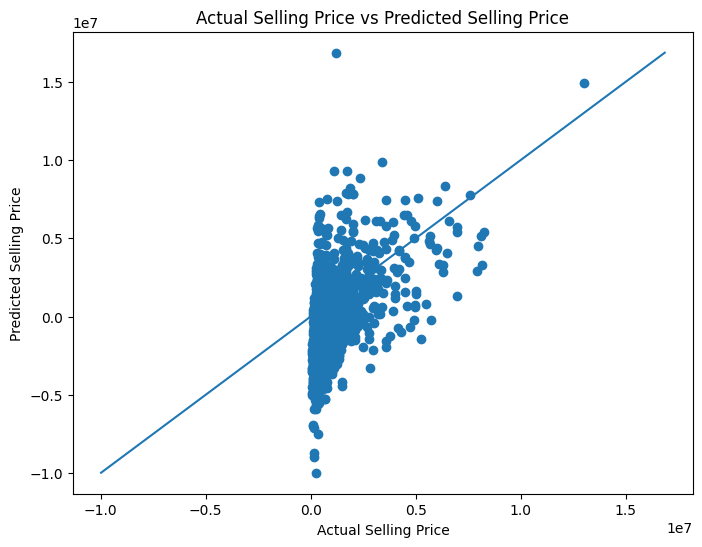

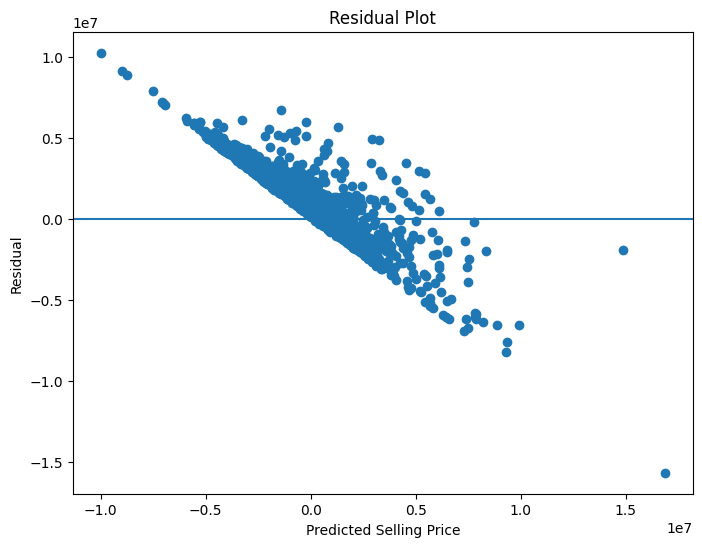

Observations with the largest prediction errors:

Observation 886: Actual = 1225000.00, Predicted = 16863313.13, Error = -15638313.13, Absolute Error = 15638313.13
Observation 2247: Actual = 270000.00, Predicted = -9981805.97, Error = 10251805.97, Absolute Error = 10251805.97
Observation 1932: Actual = 175000.00, Predicted = -8978237.29, Error = 9153237.29, Absolute Error = 9153237.29
Observation 1945: Actual = 150000.00, Predicted = -8728397.52, Error = 8878397.52, Absolute Error = 8878397.52
Observation 934: Actual = 1100000.00, Predicted = 9281730.71, Error = -8181730.71, Absolute Error = 8181730.71
Observation 1199: Actual = 350000.00, Predicted = -7532430.42, Error = 7882430.42, Absolute Error = 7882430.42
Observation 2326: Actual = 1751000.00, Predicted = 9330866.48, Error = -7579866.48, Absolute Error = 7579866.48
Observation 1484: Actual = 150000.00, Predicted = -7094077.29, Error = 7244077.29, Absolute Error = 7244077.29
Observation 481: Actual = 117000.00, Predicted = -702033

In [36]:
# Task 19: Visualize and Analyze Model Performance

import matplotlib.pyplot as plt
import numpy as np

# Convert predictions to 1D array
y_pred_flat = np.asarray(y_pred).flatten()
ytest_flat = np.asarray(ytest).flatten()

# Calculate residuals
residuals = ytest_flat - y_pred_flat

# 1. Actual Selling Price vs Predicted Selling Price
plt.figure(figsize=(8, 6))
plt.scatter(ytest_flat, y_pred_flat)

# Perfect prediction reference line
min_price = min(ytest_flat.min(), y_pred_flat.min())
max_price = max(ytest_flat.max(), y_pred_flat.max())
plt.plot([min_price, max_price], [min_price, max_price])

plt.xlabel('Actual Selling Price')
plt.ylabel('Predicted Selling Price')
plt.title('Actual Selling Price vs Predicted Selling Price')
plt.show()


# 2. Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred_flat, residuals)
plt.axhline(y=0)

plt.xlabel('Predicted Selling Price')
plt.ylabel('Residual')
plt.title('Residual Plot')
plt.show()


# 3. Identify observations with large prediction errors
absolute_errors = np.abs(residuals)

# Top 10 observations with largest errors
largest_error_indices = np.argsort(absolute_errors)[-10:][::-1]

print("Observations with the largest prediction errors:")
print()

for i in largest_error_indices:
    print(
        f"Observation {i}: "
        f"Actual = {ytest_flat[i]:.2f}, "
        f"Predicted = {y_pred_flat[i]:.2f}, "
        f"Error = {residuals[i]:.2f}, "
        f"Absolute Error = {absolute_errors[i]:.2f}"
    )


# 4. Calculate percentage of residuals above and below zero
positive_residuals = np.sum(residuals > 0)
negative_residuals = np.sum(residuals < 0)

print("\nResidual Analysis:")
print("Positive residuals:", positive_residuals)
print("Negative residuals:", negative_residuals)

# 5. Observations
print("\nObservations:")
print("1. Points close to the reference line represent accurate predictions.")
print("2. Points farther from the reference line represent larger prediction errors.")
print("3. Residuals should ideally be randomly scattered around zero.")
print("4. Systematic patterns in the residual plot may indicate that the linear model")
print("   does not fully capture the relationship between the features and selling price.")
print("5. Prediction errors may be caused by omitted variables, nonlinear relationships,")
print("   outliers, variations in car condition, brand effects, or market factors.")

### Task 20: Conclude
•
Comment on the most influential features.

•
Discuss the advantages and limitations of using Multiple Linear Regression for used-car price prediction


In [37]:
# Task 20: Conclusion

# Identify the most influential features based on absolute coefficient values
coefficients = beta[1:].flatten()
feature_names = X.columns.tolist()

importance = sorted(
    zip(feature_names, coefficients),
    key=lambda x: abs(x[1]),
    reverse=True
)

print("Most Influential Features:")
for feature, coefficient in importance:
    print(f"{feature}: {coefficient:.6f}")

print("\nConclusion:")
print("The features with larger absolute regression coefficients have relatively")
print("greater influence on the predicted selling price.")

print("\nAdvantages of Multiple Linear Regression:")
print("1. Simple and easy to understand.")
print("2. Uses multiple features simultaneously for prediction.")
print("3. Regression coefficients show the direction and relative effect of features.")
print("4. OLS can be implemented efficiently using NumPy matrix operations.")
print("5. The model is computationally inexpensive.")

print("\nLimitations of Multiple Linear Regression:")
print("1. Assumes a linear relationship between predictors and selling price.")
print("2. Sensitive to outliers and extreme observations.")
print("3. Multicollinearity can make coefficient estimates unstable.")
print("4. Important factors not included in the dataset may cause prediction errors.")
print("5. Used-car prices can depend on complex factors such as car condition,")
print("   brand reputation, demand, location, and market trends.")

Most Influential Features:
fuel_type_Diesel: 22747325626023149568.000000
engine: 22747325626022100992.000000
seats: 22747325626021052416.000000
max_power: 22747325626020003840.000000
fuel_type_CNG: 22747325626020003840.000000
fuel_type_Electric: 3438223754696327168.000000
fuel_type_LPG: 3438223754696327168.000000
fuel_type_Petrol: 3438223754696065024.000000
seller_type_Individual: -10813440.000000
seller_type_Dealer: -10158080.000000
brand: 633380.272472
seller_type_Trustmark Dealer: -61423.774358
mileage: -11133.255973
km_driven: 8894.819341
model: 5409.114730
Unnamed: 0: 141.424658
car_name: 4.216875

Conclusion:
The features with larger absolute regression coefficients have relatively
greater influence on the predicted selling price.

Advantages of Multiple Linear Regression:
1. Simple and easy to understand.
2. Uses multiple features simultaneously for prediction.
3. Regression coefficients show the direction and relative effect of features.
4. OLS can be implemented efficiently us

### Conclusion
Conclude the experiment by stating whether the Multiple Linear Regression model implemented using the OLS normal equation was able to predict used-car selling prices effectively. The conclusion should include the obtained RSS and R² values, observations regarding important features, the effect of preprocessing and feature engineering, and the limitations of using a linear regression model for real-world used-car price prediction.